Saved heatmaps/heatmap_initiate_collaboration.png
Saved heatmaps/heatmap_mean_f1_agent_0.png
Saved heatmaps/heatmap_mean_f1_agent_1.png
Saved heatmaps/heatmap_mean_redundancy_agent_0.png
Saved heatmaps/heatmap_mean_redundancy_agent_1.png
Saved heatmaps/heatmap_mean_similarity_agent_0.png
Saved heatmaps/heatmap_mean_similarity_agent_1.png
Saved heatmaps/heatmap_overall_collaboration.png
Saved heatmaps/heatmap_respond_collaboration.png
Saved heatmaps/heatmap_std_f1_agent_0.png
Saved heatmaps/heatmap_std_f1_agent_1.png
Saved heatmaps/heatmap_std_redundancy_agent_0.png
Saved heatmaps/heatmap_std_redundancy_agent_1.png
Saved heatmaps/heatmap_std_similarity_agent_0.png
Saved heatmaps/heatmap_std_similarity_agent_1.png
Saved heatmaps/heatmap_success_rate.png


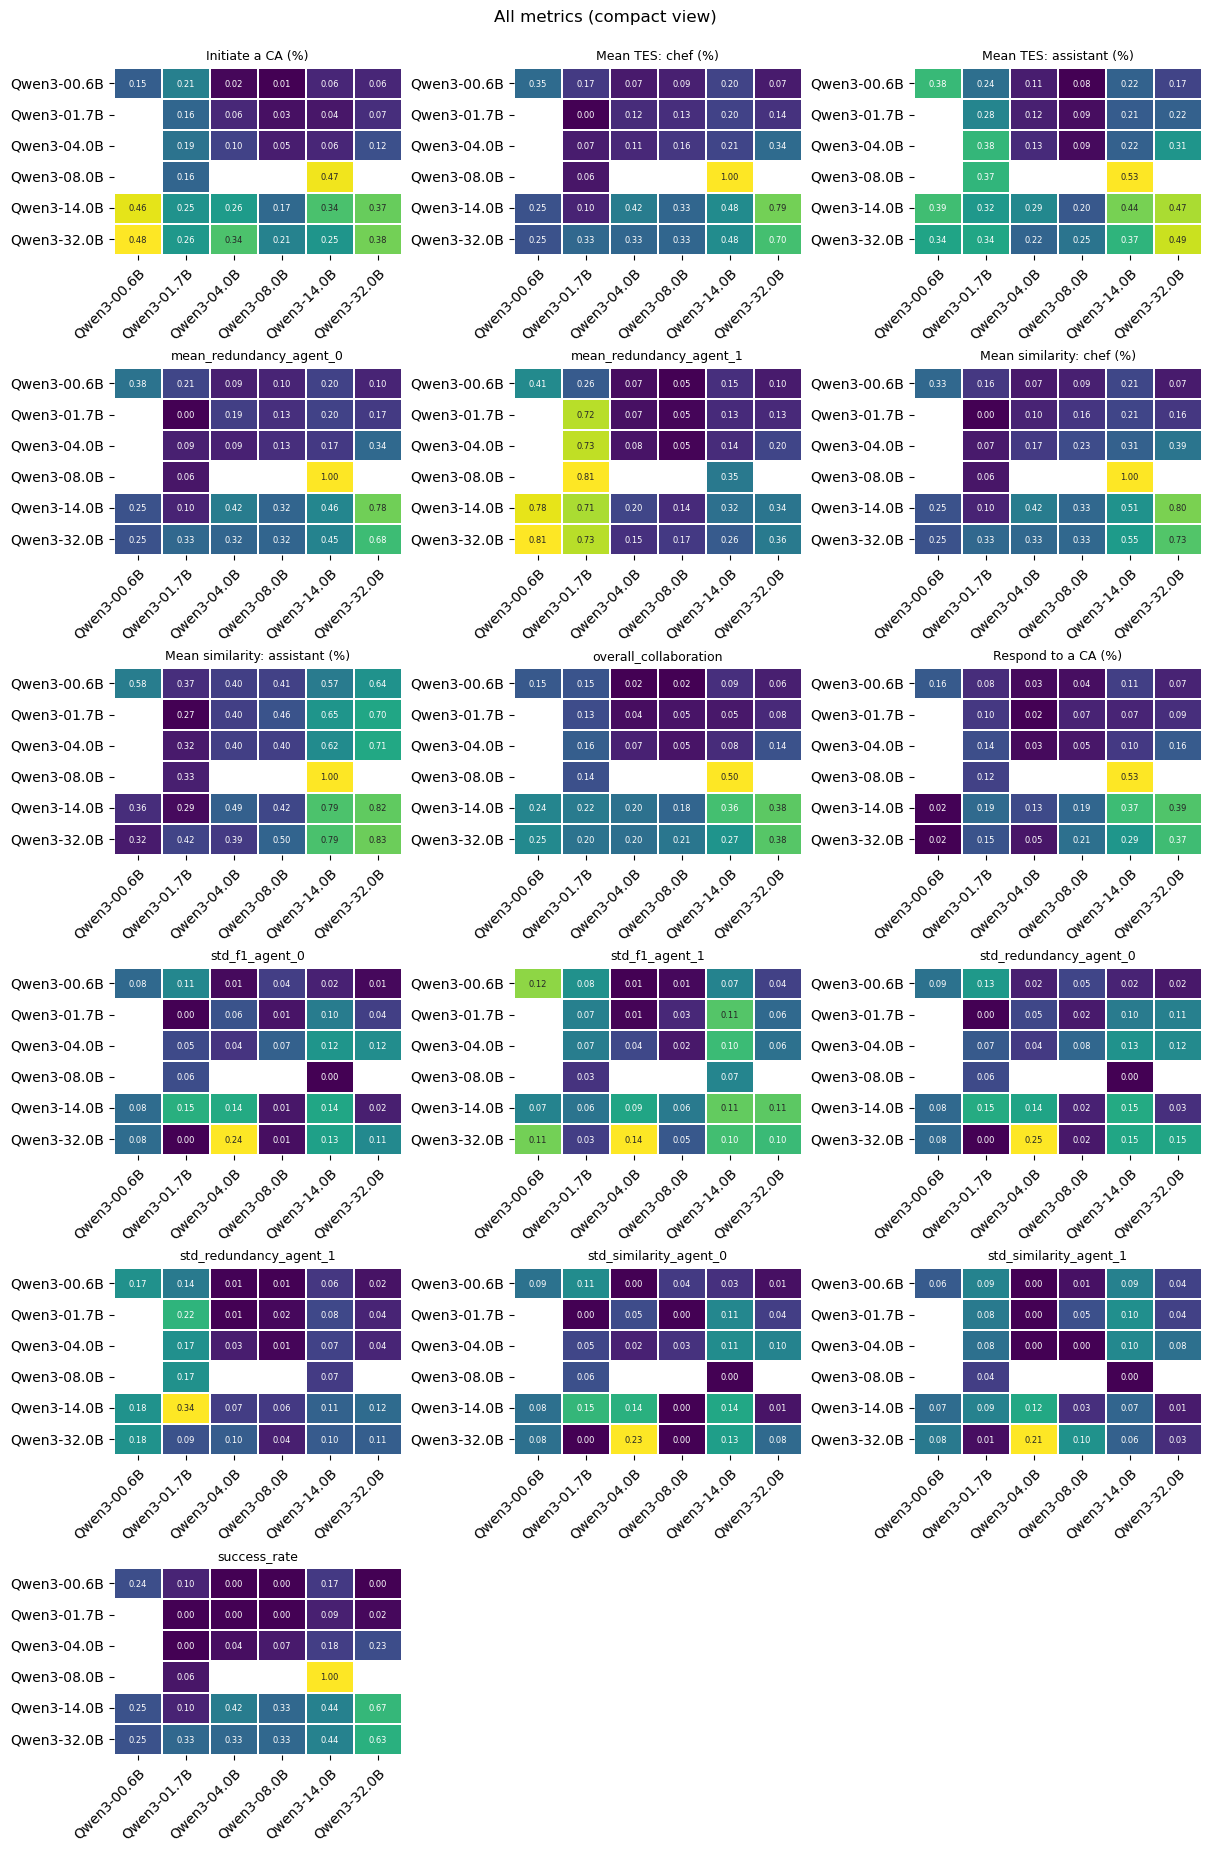

In [3]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
Generate annotated heat‑maps for every numeric metric in the input CSV.
Each metric is saved as a PNG **and** shown inline in a compact side‑by‑side
grid when run in a Jupyter notebook.

Updated: 2025‑07‑09 — visual parity + glyph‑safe text
    • Centralised heat‑map kwargs so the PNGs match the inline panels.
    • Suppressed colour‑bars in both paths; reduced individual fig size to 4 × 3.
    • **Added** normalisation step that changes the Unicode non‑breaking hyphen
      (U+2011) to the regular ASCII hyphen‑minus (U+002D) everywhere — this
      removes the "Glyph 8209 missing from font" warning in matplotlib.
    • **Fixed** title mismatch: PNG and inline heat‑maps now share identical
      titles (inline titles are the source of truth).
No other behaviour changed.
"""

import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ───────────────────────────────────────────────────────────────
# 0. User‑configurable labels  (edit below as needed)
# ───────────────────────────────────────────────────────────────
# Pretty names for models that will appear on axes ticks.
# Keys must match raw entries found in agent0_model / agent1_model
model_labels: dict[str, str] = {
    "Qwen2.5-14B-Instruct": "Qwen2.5-14B",
    "Qwen2.5-32B-Instruct": "Qwen2.5-32B",
    "Qwen2.5-7B-Instruct" : "Qwen2.5-07B",
    "Mistral-7B-Instruct-v0.1": "Mistral-07B",
    "Meta-Llama-3-8B-Instruct": "Llama3-08B",
}

# Normalise dictionary keys (replace non‑breaking hyphen with standard hyphen)
model_labels = {k.replace("\u2011", "-"): v for k, v in model_labels.items()}

# Pretty names for metric labels and colour‑bar.
metric_labels: dict[str, str] = {
    "mean_similarity_agent_0": "Mean similarity: chef (%)",
    "mean_similarity_agent_1": "Mean similarity: assistant (%)",
    "mean_f1_agent_0": "Mean TES: chef (%)",
    "mean_f1_agent_1": "Mean TES: assistant (%)",
    "initiate_collaboration": "Initiate a CA (%)",
    "respond_collaboration": "Respond to a CA (%)",
}

# Axis labels (set to blank to mirror inline view)
x_axis_label: str = ""
y_axis_label: str = ""
# Title template now mirrors inline view — PNG and inline titles are identical.
title_template: str = "{metric_label}"

# ───────────────────────────────────────────────────────────────
# 0‑bis. Centralised heat‑map styling — **single source of truth**
# ───────────────────────────────────────────────────────────────
HEATMAP_KWARGS: dict = dict(
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},    # small font, identical online/offline
    cmap="viridis",            # same colour map everywhere
    linewidths=0.25,
    linecolor="white",
    cbar=False,                # suppress colour‑bar as in notebook view
)

# ───────────────────────────────────────────────────────────────
# 1. Load and pre‑process
# ───────────────────────────────────────────────────────────────
csv_path = "converted_data_final-data.csv"
df = pd.read_csv(csv_path)

# Split the composite model column → agent0_model / agent1_model
parts = df["model"].str.split("_", expand=True)
df["agent0_model"] = parts[1]
df["agent1_model"] = parts[3]

# Replace any non‑breaking hyphens (U+2011) with the standard hyphen‑minus
for col in ("agent0_model", "agent1_model"):
    df[col] = df[col].str.replace("\u2011", "-", regex=False)

# Identify all numeric metrics (drop clearly non‑metric timing columns)
numeric_cols = (
    df.select_dtypes(include="number")
      .columns.difference(["level", "steps", "time_avg", "time_var"])
      .tolist()
)

# Aggregate duplicates: mean over (agent0, agent1, level)
group_cols = ["agent0_model", "agent1_model", "level"]
df_mean = (
    df.groupby(group_cols, dropna=False)[numeric_cols]
      .mean()
      .reset_index()
)

# ───────────────────────────────────────────────────────────────
# 2. Generate & save one heat‑map per metric (PNG)
# ───────────────────────────────────────────────────────────────
out_dir = Path("heatmaps")
out_dir.mkdir(exist_ok=True)

pivots: dict[str, pd.DataFrame] = {}  # store for composite inline plotting

for metric in numeric_cols:
    # rows = agent‑0, columns = agent‑1
    pivot = (
        df_mean
        .groupby(["agent0_model", "agent1_model"])[metric]
        .mean()
        .unstack(fill_value=np.nan)
    )

    # Apply pretty labels if provided
    pivot = pivot.rename(index=model_labels, columns=model_labels)
    metric_label = metric_labels.get(metric, metric)

    pivot = pivot.sort_index(axis=0)   # rows  (agent‑0)
    pivot = pivot.sort_index(axis=1)   # cols  (agent‑1)

    pivots[metric_label] = pivot  # store with pretty name for summary view

    # Full‑size heat‑map (individual)
    fig, ax = plt.subplots(figsize=(4, 3))  # same cell size as composite

    sns.heatmap(
        pivot,
        **HEATMAP_KWARGS,
        ax=ax,
    )

    # Unified title and blank axis labels — matches inline view
    ax.set_title(title_template.format(metric_label=metric_label), pad=8)
    ax.set_xlabel(x_axis_label)
    ax.set_ylabel(y_axis_label)

    # Diagonal x‑tick labels to avoid overlap
    ax.set_xticklabels(
        ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor"
    )

    fig.tight_layout()
    outfile = out_dir / f"heatmap_{metric}.png"
    fig.savefig(outfile, dpi=300)
    plt.close(fig)
    print(f"Saved {outfile}")

# ───────────────────────────────────────────────────────────────
# 3. Composite inline view (compact grid)
# ───────────────────────────────────────────────────────────────
try:
    n = len(pivots)
    ncols = 3  # number of plots per row
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * 4, nrows * 3),
        squeeze=False,
        constrained_layout=True,
    )

    for idx, (metric_label, pivot) in enumerate(pivots.items()):
        r, c = divmod(idx, ncols)
        ax = axes[r][c]
        sns.heatmap(
            pivot,
            **HEATMAP_KWARGS,
            ax=ax,
        )
        ax.set_title(metric_label, fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(
            ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor"
        )
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    # Hide any unused axes
    for idx in range(n, nrows * ncols):
        r, c = divmod(idx, ncols)
        axes[r][c].axis("off")

    fig.suptitle("All metrics (compact view)", y=1.02, fontsize=12)
    plt.show()
except Exception:
    # Fail quietly outside non‑interactive sessions
    pass


Figure written to self_vs_cross_play_success_rate.png


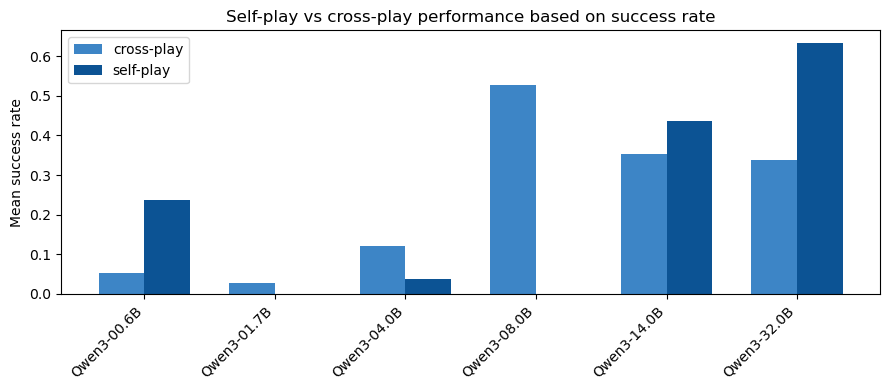

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ───────────────────────────────────────────────────────────────
# split the “family_model_family_model” string
parts = df['model'].str.split('_', expand=True)
df['agent0'] = parts[1]     # e.g. Qwen2.5-14B-Instruct
df['agent1'] = parts[3]

# average repeated runs per unordered pair
metric = 'success_rate'             # pick the metric you want
df_mean = (
    df.groupby(['agent0', 'agent1'])[metric]
      .mean()
      .reset_index()
)

# classify each row as self-play or mixed
df_mean['pair_type'] = np.where(
    df_mean['agent0'] == df_mean['agent1'],
    'self-play',
    'cross-play',
)

# ───────────────────────────────────────────────────────────────
# 2. Pivot so each model gets two columns: self-play | mixed
# ───────────────────────────────────────────────────────────────
pivot = (
    df_mean.pivot_table(index='agent0',  # one row per *reference* model
                        columns='pair_type',
                        values=metric)
          .reindex(columns=['self-play', 'cross-play'])   # consistent order
          .sort_index()
)

# ───────────────────────────────────────────────────────────────
# 3. Bar plot
# ───────────────────────────────────────────────────────────────
custom_labels = {
    'Qwen2.5-14B-Instruct': 'Qwen2.5-14B',
    'Qwen2.5-32B-Instruct': 'Qwen2.5-32B',
    'Qwen2.5-7B-Instruct' : 'Qwen2.5-07B',
    'Mistral-7B-Instruct-v0.1'  : 'Mistral-07B',
    'Meta-Llama-3-8B-Instruct'      : 'Llama3-08B',
    # add the rest…
}

pivot = pivot.rename(index=custom_labels)
pivot = pivot.sort_index(axis=0)   # rows  (agent-0)
pivot = pivot.sort_index(axis=1)   # cols  (agent-1)

models = pivot.index.tolist()         # now holds the friendly names
x      = np.arange(len(models))
models      = pivot.index.tolist()
x           = np.arange(len(models))
bar_width   = 0.35
colors      = {'self-play': '#0c5394', 'cross-play': '#3d85c6'}

fig, ax = plt.subplots(figsize=(9, 4))

# plot each category
for i, category in enumerate(pivot.columns):
    ax.bar(
        x + (i - 0.5) * bar_width,      # centre bars around each tick
        pivot[category],                # NaN automatically not plotted
        width = bar_width,
        label = category,
        color = colors[category],
    )

# cosmetics
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylabel(f'Mean success rate')
ax.set_title('Self-play vs cross-play performance based on success rate')
ax.legend()
fig.tight_layout()


fig.tight_layout()

# ──── NEW: persist the figure on disk ────
output_file = "self_vs_cross_play_success_rate.png"    # choose any name/format
fig.savefig(output_file, dpi=300, bbox_inches="tight") # <-- LINE ①
print(f"Figure written to {output_file}")              # <-- LINE ②
plt.show()

In [11]:
import networkx as nx
from io import StringIO
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
from scipy.cluster.hierarchy import linkage, dendrogram
from math import pi

In [12]:
# Split combined model string into initiator and responder
df[["initiator", "responder"]] = df["model"].str.split("_", n=1, expand=True)
df["initiator_family"] = df["initiator"].str.split("-").str[0]
df["responder_family"] = df["responder"].str.split("-").str[0]

# Derived asymmetry columns
for metric in ["mean_f1", "mean_similarity", "mean_redundancy"]:
    df[f"delta_{metric}"] = df[f"{metric}_agent_1"] - df[f"{metric}_agent_0"]

# Convenience for self-play vs cross-play
df["self_play"] = (df["initiator"] == df["responder"])

print("Data loaded:", df.shape)

Data loaded: (25, 33)


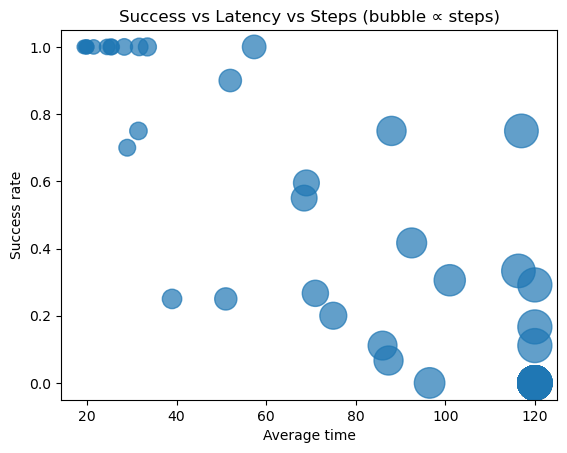

In [5]:
# ───────────────────────────────────────────────────────────────
# 4. Success–time–steps bubble chart
# ───────────────────────────────────────────────────────────────
def bubble_success_time(data):
    plt.figure()
    sizes = data["steps"] * 5
    plt.scatter(data["steps"], data["success_rate"], s=sizes, alpha=0.7)
    plt.xlabel("Average time")
    plt.ylabel("Success rate")
    plt.title("Success vs Latency vs Steps (bubble ∝ steps)")
    plt.show()

bubble_success_time(df)


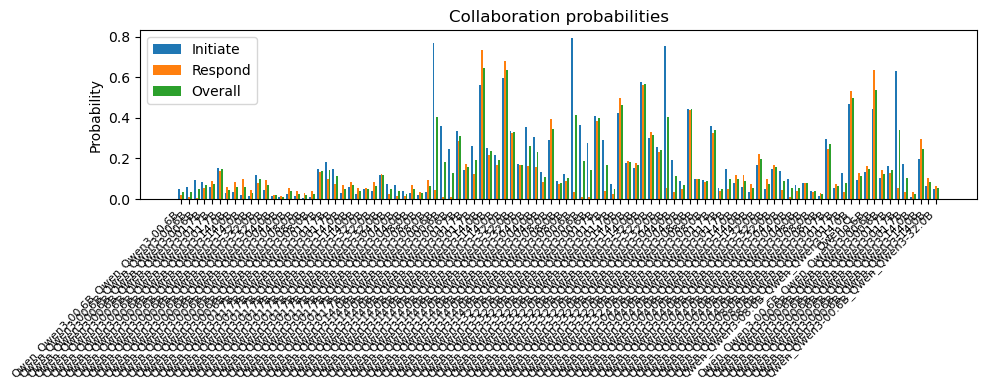

In [7]:
# ───────────────────────────────────────────────────────────────
# 6. Grouped bar chart of collaboration probabilities
# ───────────────────────────────────────────────────────────────
def grouped_collab_bars(data):
    labels = data["model"]
    x      = np.arange(len(labels))
    w      = 0.25
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(x - w, data["initiate_collaboration"], width=w, label="Initiate")
    ax.bar(x,      data["respond_collaboration"], width=w, label="Respond")
    ax.bar(x + w, data["overall_collaboration"],  width=w, label="Overall")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Probability")
    ax.set_title("Collaboration probabilities")
    ax.legend()
    plt.tight_layout()
    plt.show()

grouped_collab_bars(df)


In [35]:
import pandas as pd

# Load the CSV you uploaded
file_path = "total_result_converted_data_experiment_2025-07-09_temp_0.7_copy.csv"
df = pd.read_csv(file_path)

def parse_models(pair: str):
    """
    Split the pair string into its two constituent model names.
    Assumes the pattern: provider1_model1_provider2_model2,
    where provider names do **not** contain underscores.
    """
    parts = pair.split('_')
    # provider_i is always followed by its model name
    model_a = f"{parts[0]}_{parts[1]}"
    model_b = f"{parts[2]}_{'_'.join(parts[3:])}"
    return model_a, model_b

# Aggregate mean success‑rate for each model across all pairings
totals, counts = {}, {}
for _, row in df.iterrows():
    a, b = parse_models(row["model"])
    for m in (a, b):
        totals[m] = totals.get(m, 0) + row["success_rate"]
        counts[m] = counts.get(m, 0) + 1

mean_rates = {m: totals[m] / counts[m] for m in totals}

mean_df = (
    pd.DataFrame(mean_rates.items(), columns=["model", "mean_success_rate"])
    .sort_values("mean_success_rate", ascending=False)
    .reset_index(drop=True)
)

mean_df

,model,mean_success_rate
0,Qwen_Qwen2.5-32B-Instruct,0.464912
1,Qwen_Qwen2.5-14B-Instruct,0.458333
2,Qwen_Qwen2.5-7B-Instruct,0.140351
3,mistralai_Mistral-7B-Instruct-v0.1,0.114583
4,meta-llama_Meta-Llama-3-8B-Instruct,0.108333


In [8]:
import pandas as pd

file_path = "total_result_converted_data_experiment_2025-07-09_temp_0.7_copy.csv"
df = pd.read_csv(file_path)

def parse_models(pair: str):
    parts = pair.split('_')
    model_a = f"{parts[0]}_{parts[1]}"
    model_b = f"{parts[2]}_{'_'.join(parts[3:])}"
    return model_a, model_b

def mean_by_level(level_num: int):
    level_label = f"level_{level_num}"
    subset = df[df["level"] == level_label]
    totals, counts = {}, {}
    for _, row in subset.iterrows():
        a, b = parse_models(row["model"])
        for m in (a, b):
            totals[m] = totals.get(m, 0) + row["success_rate"]
            counts[m] = counts.get(m, 0) + 1
    mean_rates = {m: totals[m] / counts[m] for m in totals}
    mean_df = (
        pd.DataFrame(mean_rates.items(), columns=["model", "mean_success_rate"])
        .sort_values("mean_success_rate", ascending=False)
        .reset_index(drop=True)
    )
    return mean_df

lvl1_df = mean_by_level(1)

lvl2_df = mean_by_level(2)

lvl1_df

,model,mean_success_rate
0,Qwen_Qwen2.5-14B-Instruct,0.716667
1,Qwen_Qwen2.5-32B-Instruct,0.683333
2,Qwen_Qwen2.5-7B-Instruct,0.266667
3,meta-llama_Meta-Llama-3-8B-Instruct,0.216667
4,mistralai_Mistral-7B-Instruct-v0.1,0.183333


In [44]:
lvl2_df

,model,mean_success_rate
0,Qwen_Qwen2.5-32B-Instruct,0.222222
1,Qwen_Qwen2.5-14B-Instruct,0.200000
2,Qwen_Qwen2.5-7B-Instruct,0.000000
3,meta-llama_Meta-Llama-3-8B-Instruct,0.000000
4,mistralai_Mistral-7B-Instruct-v0.1,0.000000
